In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import re
import matplotlib.pyplot as plt
import numpy as np


font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }


import matplotlib.cm as cm
import matplotlib.colors as colors

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
bb_shift_data=pd.read_csv('../../../data/dihedrals/rotamer_shift/BACKBONE_ROTAMER_SHIFT_PRE_VS_BND.csv',
                         index_col=0)
bb_shift_data

,Residues,psi shift,phi shift,Max,Max BB
0,1,0.344322,0.022977,0.344322,psi
1,2,0.318348,0.000000,0.318348,psi
2,3,0.200799,0.150516,0.200799,psi
3,4,0.161838,0.019314,0.161838,psi
4,5,0.042624,0.011655,0.042624,psi
...,...,...,...,...,...
114,115,0.073260,0.000000,0.073260,psi
115,116,0.110223,0.000000,0.110223,psi
116,117,0.386613,0.000000,0.386613,psi
117,118,0.182817,0.026640,0.182817,psi


In [3]:
chi_shift_select_df=pd.read_csv('../../../data/dihedrals/rotamer_shift/SIDECHAIN_ROTAMER_SHIFT_PRE_VS_BND.csv',
                               index_col=0)
chi_shift_select_df


,CHI1,CHI2,CHI3,CHI4,RESIDUES
0,0.357198,0.459318,0.123654,0.000000,1
1,0.505717,0.506161,0.000000,0.000000,2
2,0.172938,0.000000,0.000000,0.000000,3
3,0.460872,0.513487,0.032856,0.000000,4
4,0.215784,0.355200,0.011100,0.305028,5
...,...,...,...,...,...
114,0.149406,0.000000,0.000000,0.000000,115
115,0.139860,0.035520,0.339660,0.000000,116
116,0.500833,0.212676,0.130536,0.000000,117
117,0.201576,0.000000,0.000000,0.000000,118


In [4]:
max(bb_shift_data["Max"]), max(chi_shift_select_df["CHI1"])

(0.6037296037296037, 0.63003663003663)

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_31882/1622608725.py:13: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar=plt.colorbar(f2rgb2, ticks=tk,shrink=0.3)


[Text(1, 0.0, '0.0'), Text(1, 0.3, '0.3'), Text(1, 0.6, '0.6')]

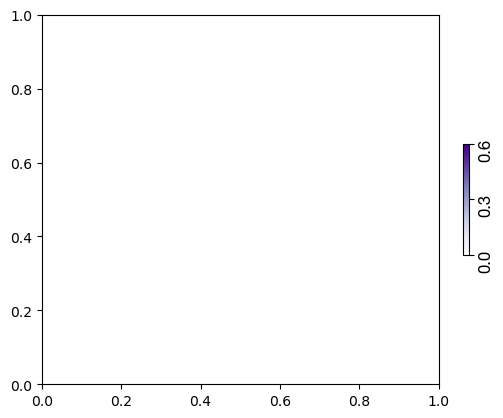

In [5]:
# SIDECHAIN_SHIFT_CBAR
mini=0
maxi=0.6
norm = colors.Normalize(vmin=mini, vmax=maxi)

cmp='Purples'


f2rgb2 = cm.ScalarMappable(norm=norm, cmap=cmp)
f2rgb2.set_array([])
tk=np.linspace(mini, maxi, 3)
tk=np.round(tk,2)
cbar=plt.colorbar(f2rgb2, ticks=tk,shrink=0.3)
cbar.ax.set_yticklabels(cbar.ax.get_yticklabels(), rotation=90,fontdict=font)


# plt.savefig('DIHEDRAL_SHIFT_UPON_MEM_BINDING/dot_hm_shift_cbar.png',
#                    dpi=450,transparent=True,
#                    bbox_inches='tight')

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_31882/4264045484.py:9: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar=plt.colorbar(f2rgb3, ticks=tk,shrink=0.3)


[Text(1, 0.0, '0.0'), Text(1, 0.3, '0.3'), Text(1, 0.6, '0.6')]

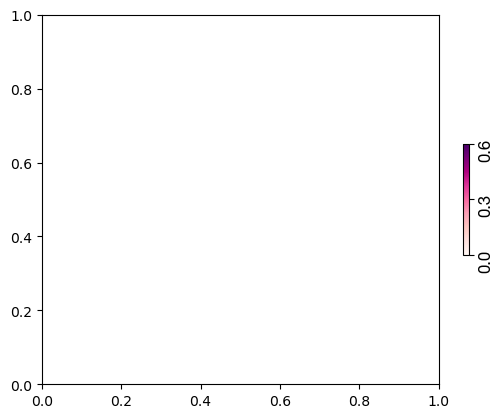

In [6]:
# BACKBONE_SHIFT_CBAR
cmp='RdPu'


f2rgb3 = cm.ScalarMappable(norm=norm, cmap=cmp)
f2rgb3.set_array([])
tk=np.linspace(mini, maxi, 3)
tk=np.round(tk,2)
cbar=plt.colorbar(f2rgb3, ticks=tk,shrink=0.3)
cbar.ax.set_yticklabels(cbar.ax.get_yticklabels(), rotation=90,fontdict=font)



In [7]:
def scaler(min_size, max_size, min_val, max_val, sizes):

    scaled_sizes = [(size - min_val) / (max_val - min_val) * (max_size - min_size) + min_size for size in sizes]

    return scaled_sizes




In [8]:
# MEM_RES=[1,2,3,4,5,6,7,8,9,10,12,36,37,38,39,40,41,42,43,44,46,80,82,84,85,112,114,115,116,117,118,119]
MEM_RES=[1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 37, 38, 39, 40, 41, 42, 43, 45, 46, 119]
pock_res=[19,23,32,34,51,53,108,35,52,54,55,58,63,66,67,70]
rest_res=[i for i in range(1,120) if i not in MEM_RES+pock_res]



membrane_binding_region=[('N-Terminal',0,10),('B1',11,12),('L3',13,20),
                        ('B3',21,22),('L6',23,24),
                         ('B4',25,26),('C-Terminal',27,32)]
rest_region=[('H2',1,12),('L2',13,15),('B1',16,18),('L3',19,23),
            ('L4',24,26),('H3',27,33),('L5',34,42),('L6',44,53),('H4',54,61),
            ('L7',62,66),('B4',67,70)]
pockets_L=[('HP1',0,7),('HP2',8,15)]

def index_ret(segment, res_n):
    if segment=='MTM':
        return(MEM_RES.index(res_n))
    elif segment=='BPM':
        return(pock_res.index(res_n))
    elif segment=='REST':
        return(rest_res.index(res_n))
    

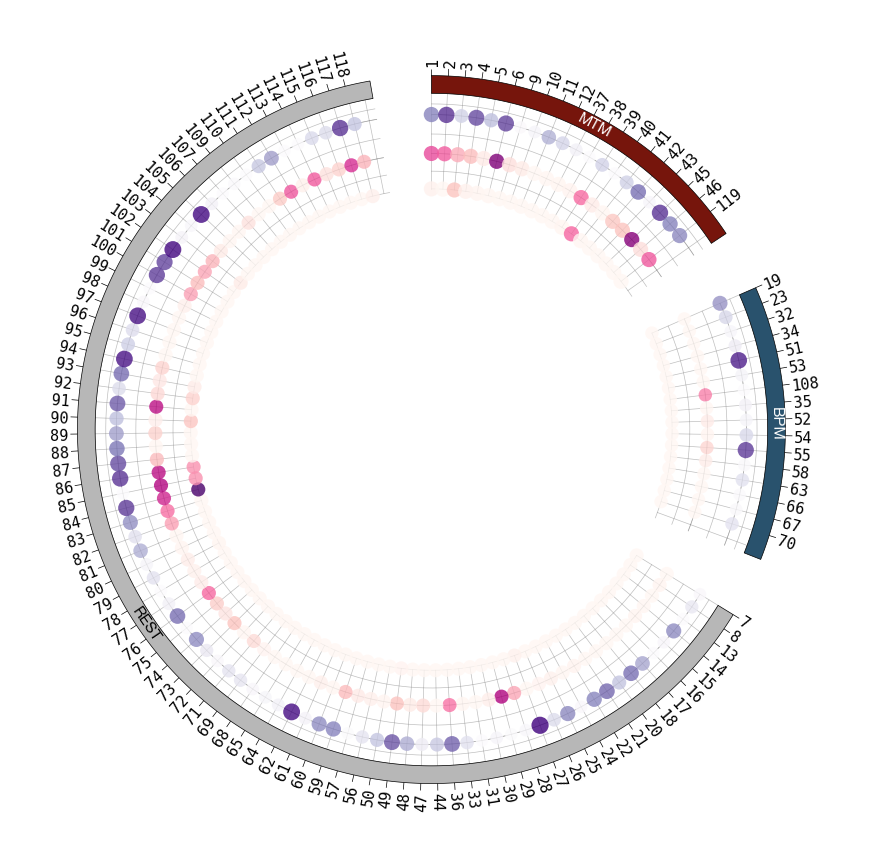

In [9]:
from pycirclize import Circos

sectors = {"MTM": len(MEM_RES)+0.6, "BPM": len(pock_res)+0.5,
          "REST":len(rest_res)+0.5,}
name2color = {"MTM": "#76150C","BPM":"#29526D","REST":"#B7B7B7",}
circos = Circos(sectors, sector2start_pos={"MEM_BINDING": 0,"POCKETS":0,
                                            "REST":0,},space=10)


c=0
for sector in circos.sectors:
    c=c+1
    if c==1:
        track = sector.add_track((100, 95),r_pad_ratio=0.5)
        track.axis(fc=name2color[sector.name])
        track.text(sector.name, color="white", size=11,
                   adjust_rotation=True,fontname="Helvetica Neue")

        track.xticks(x=[i for i in range (len(MEM_RES))],labels=[i for i in MEM_RES],
                    label_size=11,label_orientation='vertical',text_kws={'fontfamily':'monospace'})
c=0
for sector in circos.sectors:
    c=c+1
    if c==2:
        track = sector.add_track((100, 95),r_pad_ratio=0.5)
        track.axis(fc=name2color[sector.name])
        track.text(sector.name, color="white", size=11,fontname="Helvetica Neue")
        
        track.xticks(x=[i for i in range (len(pock_res))],labels=[i for i in pock_res],
                    label_size=11,label_orientation='vertical',text_kws={'fontfamily':'monospace'})
        
c=0
for sector in circos.sectors:
    c=c+1
    if c==3:
        track = sector.add_track((100, 95),r_pad_ratio=0.5)
        track.axis(fc=name2color[sector.name])
        track.text(sector.name, color="black", size=11,fontname="Helvetica Neue")
        
        track.xticks(x=[i for i in range (len(rest_res))],labels=[i for i in rest_res],
                    label_size=11,label_orientation='vertical',text_kws={'fontfamily':'monospace'})

        

for sel_range_ind, sel_range in enumerate([MEM_RES, pock_res, rest_res]):
    scatter_track = circos.sectors[sel_range_ind].add_track((89, 95), )

    x_ind_ls=[]
    col_ls=[]
    s_ls=[]
    for x_ind, x in enumerate(sel_range):
        fil_df=chi_shift_select_df[chi_shift_select_df['RESIDUES']==x]
        chi1_shift_val=fil_df['CHI1'].to_list()[0]

        col=f2rgb2.to_rgba(chi1_shift_val)[:3]
        col_ls.append(col)
        size_=scaler(80,150, 0,0.6,[chi1_shift_val])
        x_ind_ls.append(x_ind)
        s_ls.append(size_)
    scatter_track.scatter(x_ind_ls, [0 for i in x_ind_ls], color=col_ls, s=s_ls,
                         alpha=0.8)
    scatter_track.grid(y_grid_num=3, x_grid_interval=1, color="gray",lw=0.5)


    #bb_shift_data
    #----#
    scatter_track = circos.sectors[sel_range_ind].add_track((78, 89), )

    x_ind_ls=[]
    col_ls=[]
    s_ls=[]
    for x_ind, x in enumerate(sel_range):
        fil_df=bb_shift_data[bb_shift_data['Residues']==x]
        bb_shift_val=fil_df['psi shift'].to_list()[0]

        col=f2rgb3.to_rgba(bb_shift_val)[:3]
        col_ls.append(col)
        size_=scaler(80,150, 0,0.6,[chi1_shift_val])
        x_ind_ls.append(x_ind)
        s_ls.append(size_)

    scatter_track.scatter(x_ind_ls, [0 for i in x_ind_ls], color=col_ls, s=s_ls,
                         alpha=0.8)
    scatter_track.grid(y_grid_num=3, x_grid_interval=1, color="gray",lw=0.5)


    scatter_track = circos.sectors[sel_range_ind].add_track((78-10, 78), )

    x_ind_ls=[]
    col_ls=[]
    s_ls=[]
    for x_ind, x in enumerate(sel_range):
        fil_df=bb_shift_data[bb_shift_data['Residues']==x]
        bb_shift_val=fil_df['phi shift'].to_list()[0]

        col=f2rgb3.to_rgba(bb_shift_val)[:3]
        col_ls.append(col)
        size_=scaler(80,150, 0,0.6,[chi1_shift_val])
        x_ind_ls.append(x_ind)
        s_ls.append(size_)

    scatter_track.scatter(x_ind_ls, [0 for i in x_ind_ls], color=col_ls, s=s_ls,
                         alpha=0.8)
    scatter_track.grid(y_grid_num=3, x_grid_interval=1, color="gray",lw=0.5)









fig = circos.plotfig()


# plt.savefig('../../../plots/dihedrals/rotamer_shift/BB_CHI1_dihedral_shift_pre_vs_bnd.png', dpi=550,
#            transparent=True, bbox_inches='tight')

In [10]:
# Region wise rotamer shift distribution

In [9]:
def region_rotamer_returner(shift_data, region_ls):
    shift_ls=[]
    for i in region_ls:
        shift_val=shift_data[i-1]
        shift_ls.append(shift_val)
    return shift_ls

In [10]:

max_chi=[]
for i,j,k,l in zip(chi_shift_select_df['CHI1'],
                  chi_shift_select_df['CHI2'],
                  chi_shift_select_df['CHI3'],
                  chi_shift_select_df['CHI4']):
    #max_chi.append(np.max([i,j,k,l]))
    max_chi.append(i) #considering chi1 only
    
mtm_chi_shift=region_rotamer_returner(max_chi, MEM_RES)
bp_chi_shift=region_rotamer_returner(max_chi, pock_res)
rest_chi_shift=region_rotamer_returner(max_chi, rest_res)


In [11]:
max_bb=bb_shift_data['Max'].to_list()

mtm_bb_shift=region_rotamer_returner(max_bb, MEM_RES)
bp_bb_shift=region_rotamer_returner(max_bb, pock_res)
rest_bb_shift=region_rotamer_returner(max_bb, rest_res)


In [13]:
shift_region_wise=pd.DataFrame()
shift_region_wise["Residue"]=MEM_RES+pock_res+rest_res
shift_region_wise['Region']=['MTM' for i in mtm_bb_shift]+['BP' for i in bp_bb_shift]+['REST' for i in rest_bb_shift]
shift_region_wise['BB_SHIFT']=mtm_bb_shift+ bp_bb_shift+ rest_bb_shift
shift_region_wise['SC_SHIFT']=mtm_chi_shift+ bp_chi_shift+ rest_chi_shift
shift_region_wise

,Residue,Region,BB_SHIFT,SC_SHIFT
0,1,MTM,0.344322,0.357198
1,2,MTM,0.318348,0.505717
2,3,MTM,0.200799,0.172938
3,4,MTM,0.161838,0.460872
4,5,MTM,0.042624,0.215784
...,...,...,...,...
114,114,REST,0.320346,0.000000
115,115,REST,0.073260,0.149406
116,116,REST,0.110223,0.139860
117,117,REST,0.386613,0.500833


In [14]:
# shift_region_wise.to_csv("../../../../LC3_paper_data_files_for_source_data_comp/rotamer_shift_pre_vs_bnd.csv")


/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_68140/1100435434.py:15: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(x='Region', y='BB_SHIFT', data=shift_region_wise,
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of panda

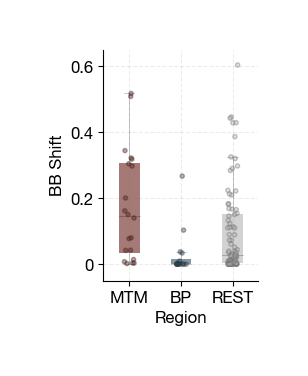

In [17]:
# Create the boxplot
fig, ax = plt.subplots(figsize=(2,3))
PROPS = {
    'boxprops':{ 'edgecolor':'none', 'alpha':0.6},
    'medianprops':{'color':'black','alpha':0.3},
    'whiskerprops':{'color':'black','alpha':0.3},
    'capprops':{'color':'black','alpha':0.3}}
#col_ls=['#63C2A7','#EDBE1F','#B8BAC0' ]
col_ls=["#76150C","#29526D","#B4B4B4"]

sns.boxplot(x='Region', y='BB_SHIFT', data=shift_region_wise, 
            showfliers=False,width=0.4,palette=col_ls,
            **PROPS,ax=ax)

sns.stripplot(x='Region', y='BB_SHIFT', data=shift_region_wise, 
              jitter=True, alpha=0.4, 
              dodge=False, palette=col_ls,
              size=3,linewidth=1,ax=ax)



ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)

#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([0,1,2], ['MTM', 'BP', 'REST'])
ax.set_xticklabels(['MTM', 'BP', 'REST'], fontdict=font)

ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)


ax.set_xlabel('Region', fontdict=font)
ax.set_ylabel('BB Shift', fontdict=font)

ax.set_ylim(-0.05,0.65)


plt.savefig('../../../plots/dihedrals/rotamer_shift/BB_SHIFT_pre_vs_bnd_regionwise.png', dpi=550,
           transparent=True, bbox_inches='tight')

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_68140/1014590738.py:15: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(x='Region', y='SC_SHIFT', data=shift_region_wise,
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of panda

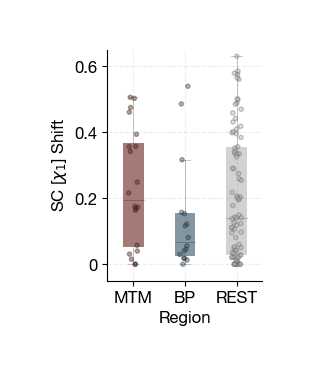

In [18]:
# Create the boxplot
fig, ax = plt.subplots(figsize=(2,3))
PROPS = {
    'boxprops':{ 'edgecolor':'none', 'alpha':0.6},
    'medianprops':{'color':'black','alpha':0.3},
    'whiskerprops':{'color':'black','alpha':0.3},
    'capprops':{'color':'black','alpha':0.3}}
# col_ls=['#63C2A7','#EDBE1F','#B8BAC0' ]
col_ls=["#76150C","#29526D","#B4B4B4"]

sns.boxplot(x='Region', y='SC_SHIFT', data=shift_region_wise, 
            showfliers=False,width=0.4,palette=col_ls,
            **PROPS,ax=ax)

sns.stripplot(x='Region', y='SC_SHIFT', data=shift_region_wise, 
              jitter=True, alpha=0.4, 
              dodge=False, palette=col_ls,
              size=3,linewidth=1,ax=ax)



ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)

#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([0,1,2], ['MTM', 'BP', 'REST'])
ax.set_xticklabels(['MTM', 'BP', 'REST'], fontdict=font)

ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)


ax.set_xlabel('Region', fontdict=font)
ax.set_ylabel('SC [$\chi_1$] Shift', fontdict=font)

ax.set_ylim(-0.05,0.65)

plt.savefig('../../../plots/dihedrals/rotamer_shift/CHI1_SHIFT_pre_vs_bnd_regionwise.png', dpi=550,
           transparent=True, bbox_inches='tight')

In [27]:
shift_region_wise[shift_region_wise["Region"]=="REST"]["BB_SHIFT"].mean(),\
shift_region_wise[shift_region_wise["Region"]=="REST"]["SC_SHIFT"].mean()

(0.0977737122315435, 0.2058370010177239)

In [23]:
shift_region_wise[shift_region_wise["Region"]=="MTM"]["BB_SHIFT"].std(),\
shift_region_wise[shift_region_wise["Region"]=="MTM"]["SC_SHIFT"].std()

(0.16699732897393108, 0.17878166858519504)

In [25]:
np.percentile(shift_region_wise[shift_region_wise["Region"]=="MTM"]["BB_SHIFT"].mean(), [25, 50]),\
np.percentile(shift_region_wise[shift_region_wise["Region"]=="MTM"]["SC_SHIFT"].mean(), [25, 50])

(array([0.17697303, 0.17697303]), array([0.23404373, 0.23404373]))

In [44]:
(shift_region_wise[shift_region_wise["Region"]=="REST"]["BB_SHIFT"]>=0.2).astype(int).sum()/\
len(shift_region_wise[shift_region_wise["Region"]=="REST"]["BB_SHIFT"])


0.18072289156626506

In [45]:
(shift_region_wise[shift_region_wise["Region"]=="REST"]["SC_SHIFT"]>=0.2).astype(int).sum()/\
len(shift_region_wise[shift_region_wise["Region"]=="REST"]["SC_SHIFT"])


0.43373493975903615

In [46]:
shift_region_wise[shift_region_wise["Region"]=="BP"]["SC_SHIFT"]>=0.2

20     True
21    False
22    False
23    False
24     True
25    False
26    False
27    False
28    False
29    False
30     True
31    False
32    False
33    False
34    False
35    False
Name: SC_SHIFT, dtype: bool

In [ ]:
# 